In [1]:
# Install TensorFlow
# !pip install -q tensorflow-gpu==2.0.0-beta1

#try:
#    %tensorflow_version 2.x  # Colab only.
# except Exception:
#    pass

import tensorflow as tf
print(tf.__version__)

2026-02-27 11:29:35.817508: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-27 11:29:36.534983: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-27 11:29:38.693598: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2.20.0


In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D 
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.models import Model

In [4]:
# baixa o arquivo spam.csv da internet
!wget https://lazyprogrammer.me/course_files/spam.csv



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://lazyprogrammer.me/cour]87[Files: 0  Bytes: 0  [0 B/s] Re]87Saving 'spam.csv'
87spam.csv              11% [==>                           ]   58.99K    --.-KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87spam.csv             100% [=============================>]  491.85K  450.90KB/s87HTTP response 200  [https://lazyprogrammer.me/course_files/spam.csv]
87spam.csv             100% [=============================>]  491.85K  450.90KB/s87[Files: 1  Bytes: 491.85K [166.]8

In [7]:
# lê o CSV com encoding específico para evitar erro de caracteres
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')

In [8]:
# mostra as 5 primeiras linhas do dataframe
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [9]:
# tirando as colunas que não precisa
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1) 

In [10]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
# renomeando colunas dnv
df.columns = ['labels', 'data']

In [13]:
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
# cria uma coluna de labels binário
df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1}) 
Y = df['b_labels'].values

In [16]:
# dividindo os dados em treino e teste
df_train, df_test, Ytrain, Ytest = train_test_split(df['data'], Y, test_size=0.33)

In [17]:
# convertendo sentenças em sequências
MAX_VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(df_train)
sequences_train = tokenizer.texts_to_sequences(df_train)
sequences_test = tokenizer.texts_to_sequences(df_test)

In [21]:
word2idx = tokenizer.word_index
V = len(word2idx)
print('found %s unique tokens' % V)

found 7268 unique tokens


In [24]:
data_train = pad_sequences(sequences_train) # padding para manter o tamanho
print('shape of data train tensor:', data_train.shape)

T = data_train.shape[1] # tamanho da sequência

shape of data train tensor: (3733, 189)


In [27]:
data_test = pad_sequences(sequences_test, 
                          maxlen=T # tamanho da sequência
                          ) # padding para manter o tamanho N x T
print('shape of data train tensor:', data_test.shape)

shape of data train tensor: (1839, 189)


In [31]:
# Create the model

# We get to choose embedding dimensionality
D = 20

# Note: we actually want to the size of the embedding to (V + 1) x D,
# because the first index starts from 1 and not 0.
# Thus, if the final index of the embedding matrix is V,
# then it actually must have size V + 1.

i = Input(shape=(T,)) # input layer
x = Embedding(V + 1, D)(i)# output layer
x = Conv1D(32, 3, activation='relu')(x) # camada de convolução
x = MaxPooling1D(3)(x) # camada de pooling
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)# camada de pooling global
x = Dense(1, activation='sigmoid')(x) # camada densa de saída,

model = Model(i, x)

In [30]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print('Training o model...')
r = model.fit(data_train, 
              Ytrain, 
              epochs=5, 
              validation_data=(data_test, Ytest))

Training o model...
Epoch 1/5
 25/117 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8122 - loss: 0.5959

2026-02-27 11:45:20.571968: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 18490560 exceeds 10% of free system memory.
2026-02-27 11:45:20.572179: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 18490560 exceeds 10% of free system memory.
2026-02-27 11:45:20.594712: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 18490560 exceeds 10% of free system memory.
2026-02-27 11:45:20.595006: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 18490560 exceeds 10% of free system memory.
2026-02-27 11:45:20.602041: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 18490560 exceeds 10% of free system memory.


117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8703 - loss: 0.3564 - val_accuracy: 0.9467 - val_loss: 0.1782
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9713 - loss: 0.0893 - val_accuracy: 0.9734 - val_loss: 0.1038
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9925 - loss: 0.0224 - val_accuracy: 0.9777 - val_loss: 0.1024
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9979 - loss: 0.0079 - val_accuracy: 0.9842 - val_loss: 0.1034
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9992 - loss: 0.0037 - val_accuracy: 0.9848 - val_loss: 0.0994


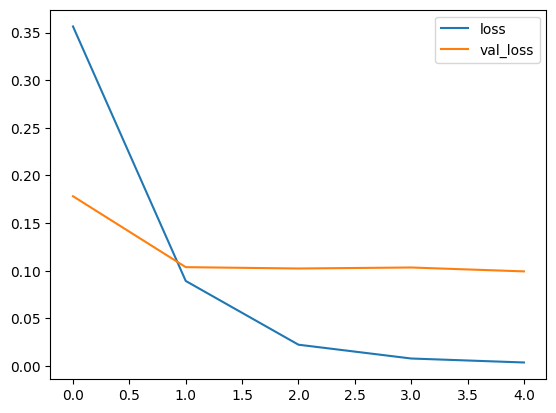

In [32]:
# plotando os resultados de erro
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

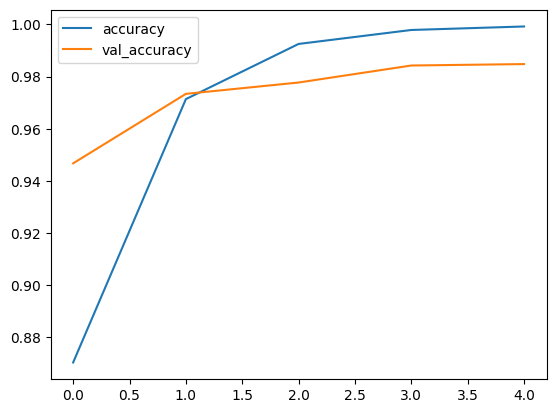

In [33]:
# plotando os resultados
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.legend()